In [30]:
import geopandas as gpd
import pandas as pd

# Load all polygon shapefiles
gdf0 = gpd.read_file("/fs9/eliviau/hex2vec_project/Eli_test/datatest/protectedareas/WDPA_WDOECM_Jun2025_Public_JPN_shp_0/WDPA_WDOECM_Jun2025_Public_JPN_shp-polygons.shp")
gdf1 = gpd.read_file("/fs9/eliviau/hex2vec_project/Eli_test/datatest/protectedareas/WDPA_WDOECM_Jun2025_Public_JPN_shp_1/WDPA_WDOECM_Jun2025_Public_JPN_shp-polygons.shp")
gdf2 = gpd.read_file("/fs9/eliviau/hex2vec_project/Eli_test/datatest/protectedareas/WDPA_WDOECM_Jun2025_Public_JPN_shp_2/WDPA_WDOECM_Jun2025_Public_JPN_shp-polygons.shp")

# Concatenate all into one GeoDataFrame
gdf_protected = pd.concat([gdf0, gdf1, gdf2], ignore_index=True)
gdf_protected = gpd.GeoDataFrame(gdf_protected, geometry="geometry")

# Confirm CRS (usually WGS84 from WDPA)
gdf_protected.crs = "EPSG:4326"
gdf_protected.head()


,WDPAID,WDPA_PID,PA_DEF,NAME,ORIG_NAME,DESIG,DESIG_ENG,DESIG_TYPE,IUCN_CAT,INT_CRIT,...,MANG_AUTH,MANG_PLAN,VERIF,METADATAID,SUB_LOC,PARENT_ISO,ISO3,SUPP_INFO,CONS_OBJ,geometry
0,726.0,726,1,Daisetsuzan,大雪山,国立公園,National Park,National,II,Not Applicable,...,Ministry of the Environment,Not Reported,State Verified,1782,JP-01,JPN,JPN,Not Applicable,Not Applicable,"POLYGON ((142.9882 43.8045, 142.98859 43.80423..."
1,727.0,727,1,Bandai asahi,磐梯朝日,国立公園,National Park,National,II,Not Applicable,...,Ministry of the Environment,Not Reported,State Verified,1782,JP-06:JP-07:JP-15,JPN,JPN,Not Applicable,Not Applicable,"MULTIPOLYGON (((140.092 37.53369, 140.09406 37..."
2,729.0,729,1,Chubusangaku,中部山岳,国立公園,National Park,National,II,Not Applicable,...,Ministry of the Environment,Not Reported,State Verified,1782,JP-15:JP-16:JP-20:JP-21,JPN,JPN,Not Applicable,Not Applicable,"POLYGON ((137.76872 36.89159, 137.76979 36.890..."
3,732.0,732,1,Chichibu tama kai,秩父多摩甲斐,国立公園,National Park,National,V,Not Applicable,...,Ministry of the Environment,Not Reported,State Verified,1782,JP-11:JP-13:JP-19:JP-20,JPN,JPN,Not Applicable,Not Applicable,"POLYGON ((138.77497 36.03851, 138.77565 36.037..."
4,733.0,733,1,Shikotsu toya,支笏洞爺,国立公園,National Park,National,II,Not Applicable,...,Ministry of the Environment,Not Reported,State Verified,1782,JP-01,JPN,JPN,Not Applicable,Not Applicable,"MULTIPOLYGON (((140.84003 42.64662, 140.84041 ..."


In [31]:
print(gdf_protected.columns.tolist())
print(gdf_protected["MARINE"].unique())


['WDPAID', 'WDPA_PID', 'PA_DEF', 'NAME', 'ORIG_NAME', 'DESIG', 'DESIG_ENG', 'DESIG_TYPE', 'IUCN_CAT', 'INT_CRIT', 'MARINE', 'REP_M_AREA', 'GIS_M_AREA', 'REP_AREA', 'GIS_AREA', 'NO_TAKE', 'NO_TK_AREA', 'STATUS', 'STATUS_YR', 'GOV_TYPE', 'OWN_TYPE', 'MANG_AUTH', 'MANG_PLAN', 'VERIF', 'METADATAID', 'SUB_LOC', 'PARENT_ISO', 'ISO3', 'SUPP_INFO', 'CONS_OBJ', 'geometry']
['0' '2' '1']


In [32]:
gdf_protected = gdf_protected[gdf_protected["MARINE"].isin(["0", "1"])]


## AHP PREP

In [33]:
# -- SELECT AREA FROM SRAI --

from srai.regionalizers import geocode_to_region_gdf

# Step 1: Get the boundary for Yamagata prefecture
area = geocode_to_region_gdf("Hokkaido, Japan")
area.crs  # should return EPSG:4326

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [34]:
# -- REGIONALIZER --
# Use Regionalizer from SRAI to regionalize the selected regions in desired resolution with H3Regionalizer 
# (here we chose 7) *we chose resolution 7 because it fits best with mesh 500x500

from srai.regionalizers import H3Regionalizer

# Step 2: Create H3 hexagons for Yamagata
regionalizer = H3Regionalizer(resolution=7)  # resolution 9 = ~500m hexes
regions = regionalizer.transform(area)

regions.head()

,geometry
region_id,
872ead465ffffff,"POLYGON ((144.02704 43.7365, 144.0232 43.74893..."
872ee6c5bffffff,"POLYGON ((140.15044 42.589, 140.14613 42.60111..."
872ef438dffffff,"POLYGON ((141.12837 43.99499, 141.1241 44.0071..."
872e132c9ffffff,"POLYGON ((144.08149 42.87292, 144.0777 42.8854..."
872e1b01dffffff,"POLYGON ((141.14556 42.93133, 141.14136 42.943..."


In [35]:
projected_crs = "EPSG:3099"

gdf_protected = gdf_protected.to_crs(projected_crs)
regions = regions.to_crs(projected_crs)


In [39]:
import geopandas as gpd

# Create a join flag: only the region_id matters
regions_with_flag = gpd.sjoin(regions, gdf_protected[["geometry"]], how="left", predicate="intersects")


In [40]:
regions_with_flag.head()

,geometry,index_right
region_id,,
872ead465ffffff,"POLYGON ((1227057.47 4882372.75, 1226596.338 4...",NaN
872ee6c5bffffff,"POLYGON ((922639.478 4728048.868, 922203.626 4...",NaN
872ef438dffffff,"POLYGON ((991411.261 4889606.823, 990968.388 4...",NaN
872e132c9ffffff,"POLYGON ((1241965.846 4786885.992, 1241505.514...",NaN
872e1b01dffffff,"POLYGON ((1001541.458 4771546.854, 1001099.245...",4.0


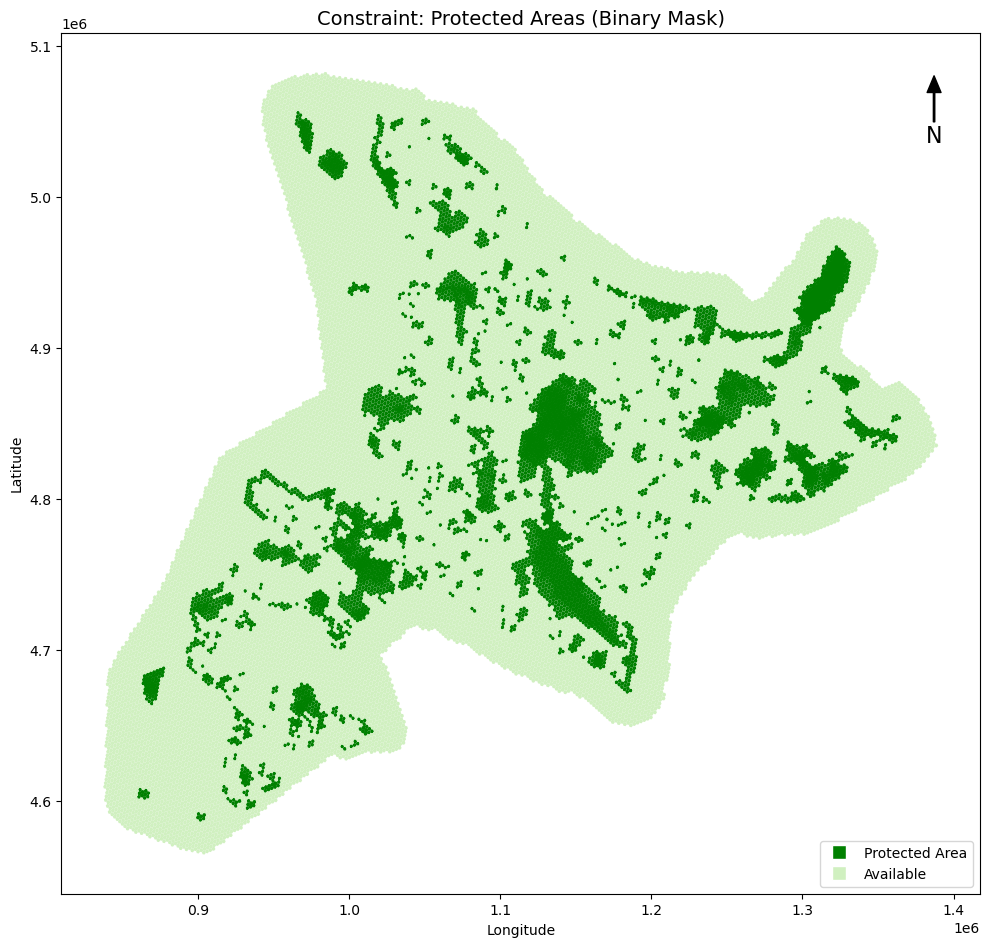

In [22]:
import geopandas as gpd
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# Make sure you have a binary column first
regions_with_flag["is_protected"] = regions_with_flag["index_right"].notnull().astype(int)

# 1. Create the figure and axis
fig, ax = plt.subplots(figsize=(10, 10))

# 2. Plot constrained regions in black
regions_with_flag[regions_with_flag["is_protected"] == 1].plot(
    color='green',
    ax=ax,
    edgecolor='none',
    label='Protected Area'
)

# 3. Plot unconstrained regions in light green
regions_with_flag[regions_with_flag["is_protected"] == 0].plot(
    color='#d0f0c0',
    ax=ax,
    edgecolor='none',
    label='Available'
)

# 4. Add legend manually
legend_elements = [
    plt.Line2D([0], [0], marker='s', color='w', label='Protected Area', markerfacecolor='green', markersize=10),
    plt.Line2D([0], [0], marker='s', color='w', label='Available', markerfacecolor='#d0f0c0', markersize=10)
]
ax.legend(handles=legend_elements, loc='lower right')

# 5. Grid, title, and north arrow
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Constraint: Protected Areas (Binary Mask)", fontsize=14)

# Add north arrow
ax.annotate('N',
            xy=(0.95, 0.95), xytext=(0.95, 0.88),
            xycoords='axes fraction',
            ha='center', va='center',
            fontsize=16,
            arrowprops=dict(facecolor='black', width=1, headwidth=10)) 

plt.tight_layout()
plt.show()


In [41]:
# Step 1 – Create binary column: 1 if intersects, 0 otherwise
regions_with_flag["is_protected"] = regions_with_flag["index_right"].notnull().astype(int)


In [42]:
regions_with_flag.head()

,geometry,index_right,is_protected
region_id,,,
872ead465ffffff,"POLYGON ((1227057.47 4882372.75, 1226596.338 4...",NaN,0
872ee6c5bffffff,"POLYGON ((922639.478 4728048.868, 922203.626 4...",NaN,0
872ef438dffffff,"POLYGON ((991411.261 4889606.823, 990968.388 4...",NaN,0
872e132c9ffffff,"POLYGON ((1241965.846 4786885.992, 1241505.514...",NaN,0
872e1b01dffffff,"POLYGON ((1001541.458 4771546.854, 1001099.245...",4.0,1


In [43]:

# Step 3 – Save to GeoJSON or Shapefile
regions_with_flag.to_file("protectedareas_hokkaido.geojson", driver="GeoJSON")
